In [122]:
import pandas as pd
import numpy as np
from pathlib import Path
import sklearn.metrics as skm
from matplotlib import pyplot as plt
import glob
import re
import time
from scipy.optimize import curve_fit
path = Path('/ix/rbao/Projects/HCC-CBS-068-Hillman-ASinghi-2/data/biliseq_he_class/proc/v6')
use = 'tiles'
re_class= r"class_(.+)_x\d+_y\d+.jpg"
re_slide =r'(.+)_class_\S+_x\d+_y\d+.jpg$'
re_slide_class=r'(.+)_class_(.+)_x\d+_y\d+.jpg$'
slides=[]
slides_c=[]
all_c=[]
all_f=[]
fns = glob.glob(str(path.joinpath(use)) + '/*.jpg')
for f in fns:
    fn=Path(f).parts[-1]
    all_f.append(fn)
    slide, c = re.findall(re_slide_class,fn)[0]
    slides_c.append("%s_%s" % (slide,c))
    slides.append(slide)
    all_c.append(c)
print(np.unique(slides_c),len(slides_c))

u_slides_c=np.unique(slides_c)
u_slides = [item.split('_') for item in u_slides_c]
slide_summary={'slide':[],'n_tiles':[],'class':[]}
for slide,clss in u_slides:
    slide_summary['slide'].append(slide)
    slide_summary['n_tiles'].append(np.sum(np.array(slides) == slide))
    slide_summary['class'].append(clss)
                                    
ss = pd.DataFrame(slide_summary)

['1007466_neg' '1007467_neg' '1007468_neg' '1007469_neg' '1007470_neg'
 '1007471_neg' '1007473_neg' '1007474_neg' '1007476_pos' '1007477_pos'
 '1007478_pos' '1007482_pos' '1007484_pos' '1007485_pos' '1007486_pos'
 '1007720_neg' '1007726_neg' '1007731_pos' '1007733_pos' '1007820_neg'
 '1007821_neg' '1007822_neg' '1007824_neg' '1007825_neg' '1007826_pos'
 '1007827_pos' '1007828_pos' '1007829_pos' '1007830_pos' '1007831_pos'
 '1007832_pos' '1007845_neg' '1007846_neg' '1007847_neg' '1007848_neg'] 51813


In [25]:
u_slides

[['1007466', 'neg'],
 ['1007467', 'neg'],
 ['1007468', 'neg'],
 ['1007469', 'neg'],
 ['1007470', 'neg'],
 ['1007471', 'neg'],
 ['1007473', 'neg'],
 ['1007474', 'neg'],
 ['1007476', 'pos'],
 ['1007477', 'pos'],
 ['1007478', 'pos'],
 ['1007482', 'pos'],
 ['1007484', 'pos'],
 ['1007485', 'pos'],
 ['1007486', 'pos'],
 ['1007720', 'neg'],
 ['1007726', 'neg'],
 ['1007731', 'pos'],
 ['1007733', 'pos'],
 ['1007820', 'neg'],
 ['1007821', 'neg'],
 ['1007822', 'neg'],
 ['1007824', 'neg'],
 ['1007825', 'neg'],
 ['1007826', 'pos'],
 ['1007827', 'pos'],
 ['1007828', 'pos'],
 ['1007829', 'pos'],
 ['1007830', 'pos'],
 ['1007831', 'pos'],
 ['1007832', 'pos'],
 ['1007845', 'neg'],
 ['1007846', 'neg'],
 ['1007847', 'neg'],
 ['1007848', 'neg']]

Text(0.5, 1.0, 'Median : 882 tiles')

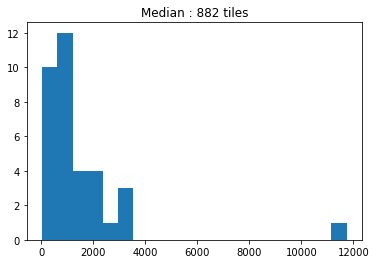

In [30]:
u_slides_c=np.unique(slides_c)
u_slides = [item.split('_') for item in u_slides_c]
slide_summary={'slide':[],'n_tiles':[],'class':[]}
for slide,clss in u_slides:
    slide_summary['slide'].append(slide)
    slide_summary['n_tiles'].append(np.sum(np.array(slides) == slide))
    slide_summary['class'].append(clss)
                                    
ss = pd.DataFrame(slide_summary)
plt.hist(ss.loc[:,'n_tiles'],20)
plt.title('Median : %d tiles' % np.median(ss.loc[:,'n_tiles']))

In [36]:
np.sort(ss.loc[:,'n_tiles'])

array([   30,    32,   187,   230,   271,   313,   487,   528,   552,
         610,   620,   650,   686,   714,   731,   766,   815,   882,
         996,  1010,  1152,  1196,  1359,  1486,  1497,  1688,  1794,
        1836,  1883,  2149,  2942,  3056,  3409,  3520, 11736])

In [128]:
#For all model types in learning curve, generate fold_summary.csv
nslides=len(np.unique(slides_c))

model_types = ['resnet18_2train_100rep_50bal',
               'resnet18_2train_100rep_100bal',
               'resnet18_2train_100rep_500bal',
               'resnet18_4train_100rep_500bal',
               'resnet18_8train_100rep_500bal',
               'resnet18_16train_100rep_500bal',
               'resnet18_24train_100rep_500bal',
               'resnet18_30train_100rep_500bal',
               'resnet18_10fold10rep']
use='tiles'
model_path='%s_model' % use
start=0
stop=100 #nslides
u_slides_c=np.unique(slides_c)
temp = [item.split('_') for item in u_slides_c]

s=time.time()

# rerun='None'
rerun='resnet18_24train_100rep_500bal'
for model_type in model_types:
    export_path=path.joinpath(model_path).joinpath(model_type).joinpath('fold_models')
    csv_path=path.joinpath(model_path).joinpath(model_type).joinpath('csv')
    infer_path=path.joinpath(model_path).joinpath(model_type).joinpath('infer_csv')
    fold_df=pd.DataFrame(ss,columns=['slide','class','n_tiles'])
    fn=infer_path.joinpath('fold_summary.csv')
    if fn.exists() == False or (rerun in model_type):
        for fold in range(start,stop):
            # print('Perform inference on fold :', fold)
            df=pd.read_csv(infer_path.joinpath('fold_%d_all_valid_pred.csv' % fold))
            test_df=df.loc[df.loc[:,'is_valid']==1,:].reset_index(drop=True)
            test_slides=np.unique(test_df.loc[:,'slide'])
            p=np.array(test_df.loc[:,'p_pos']) # Probability ['neg','pos'] (Can check with dls.vocab )
            c=np.array(test_df.loc[:,'pred_cls']) #Predictions decoded
            fold_df['p1_fold_%d' % fold] = np.zeros((fold_df.shape[0],1))*np.nan
            # fold_df['wta_fold_%d' % fold] = np.zeros((fold_df.shape[0],1))*np.nan
            for slide in test_slides:
                src_idx = np.array(test_df.loc[:,'slide']) == slide
                p1 = np.mean(p[src_idx])
                dest_idx = np.array(fold_df.loc[:,'slide'])== str(slide)
                fold_df.loc[dest_idx,'p1_fold_%d' % fold] = p1
#         stop_time=time.time()
        print('Saving inference summary to %s' % fn)
        fold_df.to_csv(fn)
print('Finished')

Saving inference summary to /ix/rbao/Projects/HCC-CBS-068-Hillman-ASinghi-2/data/biliseq_he_class/proc/v6/tiles_model/resnet18_24train_100rep_500bal/infer_csv/fold_summary.csv
Finished


In [129]:
[100]*5

[100, 100, 100, 100, 100]

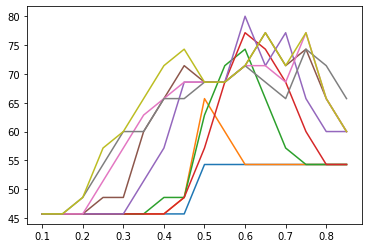

In [132]:
total_slides=35

#Initialize storage dataframe to sizes of 'resnet18_10fold10rep' tiles model:
model_type='resnet18_10fold10rep'
pn = path.joinpath('%s_model' % 'tiles').joinpath(model_type).joinpath('infer_csv')
fold_df= pd.read_csv(pn.joinpath('fold_summary.csv'))
ens=pd.DataFrame(fold_df.loc[:,('slide','class')])


# model_types = ['resnet18_2train_100rep_500bal',
#                'resnet18_4train_100rep_500bal',
#                'resnet18_16train_100rep_500bal',
#                'resnet18_24train_100rep_500bal',
#                ]

folds = [100] * len(model_types)
ntiles=[]
total_slides=len(fold_df.loc[:,'slide'])
for model_type in model_types:
    
    if 'train' in model_type:
        n_slides = int(model_type.split('_')[1].split('train')[0])
        tile_per_slide = int(model_type.split('_')[3].split('bal')[0])
    elif 'fold' in model_type: #'resnet18_10fold10rep'
        tile_per_slide=500
        n_folds = int(model_type.split('_')[1].split('fold')[0])
        n_slides = total_slides - (total_slides//n_folds)
        
    ntiles.append(tile_per_slide * n_slides)

nslides=[total_slides] * len(model_types)
use='tiles'
model_path='%s_model' % use

for use in model_types:    
    ens['%s_p1' % use]=np.zeros((total_slides,1))+np.nan
    
for use_fold,nslide,model_type in zip(folds,nslides,model_types):
    pn = path.joinpath(model_path).joinpath(model_type).joinpath('infer_csv')
    fold_df= pd.read_csv(pn.joinpath('fold_summary.csv'))
    p1=[]
    for fold in range(0,use_fold):
        p1.append(np.array(fold_df.loc[:,'p1_fold_%d' % fold]))
    p1=np.array(p1).transpose()
    m_p1=np.nanmean(p1,axis=1) #Average validation performance across model repetitions for given architecture
    #In case there are any models that failed to make a prediction for a slide, carefully merge models to final df:
    for slide in fold_df.loc[:,'slide']:
        indx=np.argwhere(np.array(fold_df.loc[:,'slide'] == slide)).flatten()
        ens.loc[indx,'%s_p1' % model_type]=m_p1[indx]

true_pos = np.array(ens.loc[:,'class'])=='pos'
thresh=np.arange(0.1,0.9,0.05)
plt.figure()
for use in model_types:
    accuracy=[]
    for t in thresh:
        pred_pos = ens.loc[:,'%s_p1' % use]> t
        # print(np.sum(true_pos == pred_pos) / len(true_pos))
        accuracy.append(np.sum(true_pos == pred_pos) / len(true_pos) * 100)
    plt.plot(thresh,accuracy)

In [133]:
ens.head()

,slide,class,resnet18_2train_100rep_50bal_p1,resnet18_2train_100rep_100bal_p1,resnet18_2train_100rep_500bal_p1,resnet18_4train_100rep_500bal_p1,resnet18_8train_100rep_500bal_p1,resnet18_16train_100rep_500bal_p1,resnet18_24train_100rep_500bal_p1,resnet18_30train_100rep_500bal_p1,resnet18_10fold10rep_p1
0,1007466,neg,0.462623,0.527610,0.607568,0.645563,0.597590,0.582846,0.583588,0.592579,0.599697
1,1007467,neg,0.460429,0.485963,0.518852,0.479669,0.371713,0.333649,0.282772,0.298274,0.237741
2,1007468,neg,0.473725,0.508873,0.544317,0.537556,0.462991,0.397571,0.367584,0.356665,0.347948
3,1007469,neg,0.466989,0.495334,0.507434,0.481855,0.300022,0.232994,0.206555,0.181919,0.185517
4,1007470,neg,0.464405,0.487203,0.478802,0.556491,0.645629,0.658319,0.686282,0.682855,0.636327


resnet18_2train_100rep_50bal
0.5428571428571428
AUROC 0.592, Sensitivity: 0.00, Specificity: 1.00

resnet18_2train_100rep_100bal
0.5428571428571428
AUROC 0.789, Sensitivity: 0.00, Specificity: 1.00

resnet18_2train_100rep_500bal
0.5714285714285714
AUROC 0.829, Sensitivity: 0.06, Specificity: 1.00

resnet18_4train_100rep_500bal
0.6857142857142857
AUROC 0.819, Sensitivity: 0.31, Specificity: 1.00

resnet18_8train_100rep_500bal
0.7714285714285715
AUROC 0.832, Sensitivity: 0.50, Specificity: 1.00

resnet18_16train_100rep_500bal
0.7142857142857143
AUROC 0.836, Sensitivity: 0.50, Specificity: 0.89

resnet18_24train_100rep_500bal
0.6857142857142857
AUROC 0.803, Sensitivity: 0.56, Specificity: 0.79

resnet18_30train_100rep_500bal
0.6571428571428571
AUROC 0.809, Sensitivity: 0.56, Specificity: 0.74

resnet18_10fold10rep
0.7142857142857143
AUROC 0.839, Sensitivity: 0.56, Specificity: 0.84



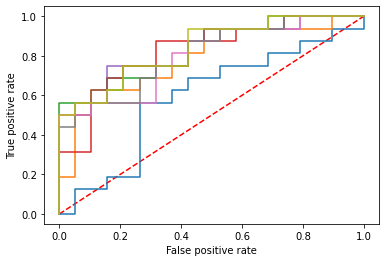

In [134]:
true_pos = np.array(ens.loc[:,'class'])=='pos'
plt.figure()
plt.plot([0,1],[0,1],'--r')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
thr = 0.7
for model_type in model_types:
    m_p1 = ens.loc[:,'%s_p1' % model_type]
#     m_p1=  np.zeros(ens.loc[:,'%s_p1' % model_type].shape) + 0.5 #Chance?
    pred_pos = m_p1 > thr
    print(model_type)
    print(np.sum(pred_pos == true_pos) / len(true_pos) )

    fpr,tpr,thresh =skm.roc_curve(true_pos,m_p1)
    plt.plot(fpr,tpr)
   
    c=skm.confusion_matrix(true_pos,pred_pos)
    auc=skm.auc(fpr,tpr)

    tn=c[0][0]
    tp=c[1][1]
    fn=c[1][0]
    fp=c[0][1]

    sensitivity = tp/(tp + fn) #True pos / all positive
    # print('sensitivity',sensitivity)

    specificity = tn/(fp + tn)
    # print('specificity',specificity) #True neg / all negative
    print('AUROC %1.3f, Sensitivity: %1.2f, Specificity: %1.2f\n'% (auc,sensitivity,specificity))
    

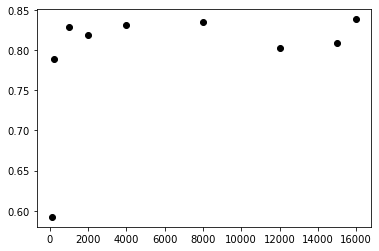

In [160]:
# model_types = ['resnet18_2train_100rep_100bal',
#                'resnet18_2train_100rep_500bal',
#                'resnet18_4train_100rep_500bal',
#                'resnet18_16train_100rep_500bal',
#                'resnet18_24train_100rep_500bal',
#                 'resnet18_10fold10rep',
#                ]
thr = 0.65
pcor=[]#[19/35]
auc=[] #[0.5]
# x = [100, 2*100, 2*500, 4*500, 16*500, 24*500, (35-35//10)*500]
# x = [1, 2, 4, 16, 24, 32]
x=ntiles
sensitivity=[]
specificity=[]
for model_type in model_types:
    m_p1 = ens.loc[:,'%s_p1' % model_type]
    pred_pos = m_p1 > thr
    pcor.append(np.sum(pred_pos == true_pos) / len(true_pos) )
    fpr,tpr,thresh =skm.roc_curve(true_pos,m_p1)
    auc.append(skm.auc(fpr,tpr))
    
    c=skm.confusion_matrix(true_pos,pred_pos)
    tn=c[0][0]
    tp=c[1][1]
    fn=c[1][0]
    fp=c[0][1]
    
    sensitivity.append(tp/(tp + fn)) #True pos / all positive   
    specificity.append(tn/(fp + tn)) #True neg / all negative
plt.plot(x,auc,'ok')

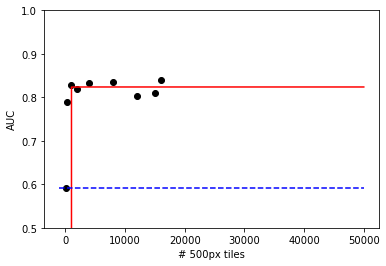

In [168]:
#Try fitting inverse power law:
def inv_power_law(x,a,b,c):
    return (1-a) - b * x**c
def power_law(x,a,b,c):
    return a + b * x**c

use = 'auc'
use_y= eval(use)
p0=[0.01,1,-0.5]
popt, pcov = curve_fit(inv_power_law, 
                       x,
                       use_y,
                       p0=p0)
plt.plot(x,use_y,'ok')
xx=np.linspace(1,5e4,50)
yy=inv_power_law(xx,popt[0],popt[1],popt[2])
plt.plot(xx,yy,'r')
plt.ylim([0.5, 1])
if use == 'pcor':
    plt.ylabel('Accuracy')
else: 
    plt.ylabel(use.upper())
plt.xlabel('# 500px tiles')
plt.plot([-1e3,5e4],[use_y[0]]*2,'--b')

In [83]:
def power_law(x,a,b,c):
    return a + b * x**c

use_y=specificity

p0=[0.01,1,0.5]
popt, pcov = curve_fit(power_law, 
                       x,
                       use_y,
                       p0=p0)
plt.plot(x,use_y,'ok')
xx=np.linspace(1,100,50)
yy=power_law(xx,popt[0],popt[1],popt[2])
plt.plot(xx,yy,'r')

RuntimeError: Optimal parameters not found: Number of calls to function has reached maxfev = 800.